In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

import scipy
from scipy.optimize import minimize_scalar
from scipy.special import expit, logit
from scipy.stats import norm

import multiprocessing as mp

import sys

parent_dir = ".."
sys.path.append(parent_dir)

import utilities as utils

In [8]:
metadata_df = pd.read_csv("processed/session_metadata.csv")
trials_df = pd.read_csv("processed/trials.csv")

sigma_vals = trials_df['sigma'].unique()
Hvals = trials_df['hazard_left'].unique()
mean_left_ = metadata_df['source_left_x'].iat[0]
mean_right_ = metadata_df['source_right_x'].iat[0]
mean_left = mean_left_ - (mean_left_ + mean_right_)/2
mean_right = mean_right_ - (mean_left_ + mean_right_)/2

/tmp/ipykernel_54917/1055454537.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trials_df = pd.read_csv("processed/trials.csv")


In [4]:
def P_source_g_samples(samples_arr,mean_left,mean_right,std,h,P0,window_size=None):
    P_sample_g_left = norm(loc=mean_left, scale=std)
    P_sample_g_right = norm(loc=mean_right, scale=std)
    Lleft = P_sample_g_left.pdf(samples_arr)
    Lright = P_sample_g_right.pdf(samples_arr)
    L = np.concatenate((Lleft[:,np.newaxis,:],Lright[:,np.newaxis,:]),axis=1)
    H = np.array([
        [1-h, h],
        [h, 1-h]
    ])
    P = P0.copy()
    if window_size is not None:
        L = L[:,:,-window_size:]
    for ii in range(L.shape[2]):
        P = L[:,:,ii][:,:,np.newaxis] * (H @ P)
    P = P / P.sum(axis=1, keepdims=True)
    return P.squeeze()

In [5]:
import multiprocessing as mp

def generate_trials(n_trials, n_draws, source_means, scale, H, mirror_trials=False, balanced_starts=False, seed=None):
    """Generate trials from a two-state switching Gaussian process.

    Parameters
    ----------
    n_trials : int
        Number of independent trials to generate.
    balanced_starts : bool, default=False
        If True, exactly half of the trials start in each source
        distribution. This requires an even ``n_trials``.
    seed : int or None, default=None
        Seed for NumPy's random-number generator. Use an integer for
        reproducible simulations.

    Returns
    -------
    X : ndarray of float, shape (n_trials, n_draws)
        Observations for each trial.
    Y : ndarray of int, shape (n_trials,)
        Identity of the source for the final draw: 0 denotes the Gaussian
        with mean source_means[0] and 1 denotes the Gaussian with mean source_means[1].
    """
    if isinstance(n_trials, (bool, np.bool_)) or not isinstance(n_trials, (int, np.integer)):
        raise TypeError("n_trials must be an integer")
    if n_trials < 0:
        raise ValueError("n_trials must be non-negative")
    if (balanced_starts or mirror_trials) and n_trials % 2:
        raise ValueError("balanced_starts=True or mirror_trials=True requires an even n_trials")

    rng = np.random.default_rng(seed)
    source_means = np.array(source_means)

    if mirror_trials:
        n_trials_ = n_trials // 2
    else:
        n_trials_ = n_trials

    if balanced_starts:
        starts = np.repeat([0, 1], n_trials_ // 2)
        rng.shuffle(starts)
    else:
        starts = rng.integers(0, 2, size=n_trials_)

    print(starts.shape)
    print(n_trials_)
    # switches[:, j] indicates whether the source changes between draws
    # j and j + 1. Cumulative parity therefore gives the source at each draw.
    switches = rng.random((n_trials_, n_draws - 1)) < H
    source_paths = np.column_stack(
        [starts, starts[:, None] ^ np.logical_xor.accumulate(switches, axis=1)]
    ).astype(int)

    raw_draws = rng.normal(loc=source_means[source_paths], scale=scale)
    X = raw_draws # np.rint(np.clip(raw_draws, -90, 90)).astype(int)
    Y = source_paths[:, -1].copy()
    if mirror_trials:
        X = np.concatenate([X, -X], axis=0)
        Y = np.concatenate([Y, 1-Y], axis=0)
    return X, Y

def IB_fn_emp(beta,p_RgX_emp,Yemp):
    Ixr = utils.compute_I_XR_emp(p_RgX_emp)
    Iry = utils.compute_I_RY_emp(p_RgX_emp,Yemp)
    return Ixr - beta*Iry

def mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True):

    rng = np.random.default_rng(seed)

    N_y = p_YgX_sample.shape[1]
    N_x = p_YgX_sample.shape[0]

    Yoh = np.eye(N_y)[Ysample.astype(int)]

    IB_fxn_vals = []
    p_RgXs = []
    p_Rs = []
    p_YgRs = []

    for ii in range(N_inits):
        p_R = (np.ones(N_y) / N_y).reshape(1,-1)
        if init == 'random':
            p_RX = np.exp(rng.random((N_x,N_y)))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)
        elif init == 'softmax':
            if betastar is None:
                betastar = beta
            p_RgX = np.exp(betastar*p_YgX_sample) / np.sum(np.exp(betastar*p_YgX_sample),axis=1,keepdims=True)
        p_RX = p_RgX * (1/N_x)
        p_XgR = p_RX / p_R
        p_YgR = Yoh.T @ p_XgR
        IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)
        delta = 1
        iters = 0
        while (delta > 1e-15) or (iters < 100):
            # store last copy
            IB_fxn_last = IB_fxn

            # update p(r|x)
            p_RX = p_R * np.exp(beta*(p_YgX_sample @ np.log(p_YgR))) # we can simplify the original update rule (below) to this
            # p_RX = p_R * np.exp(-beta*np.sum(p_YgX[:,:,np.newaxis] * (np.log(p_YgX[:,:,np.newaxis]) - np.log(p_YgR[np.newaxis,:,:])),axis=1))
            p_RgX = p_RX / np.sum(p_RX,axis=1,keepdims=True)


            # update p(r)
            p_R = p_RgX.sum(axis=0,keepdims=True) / N_x

            #update p(y|r)
            p_RX = p_RgX * (1/N_x)
            p_XgR = p_RX / p_R
            p_YgR = Yoh.T @ p_XgR

            IB_fxn = IB_fn_emp(beta,p_RgX,Ysample)

            delta = np.abs(IB_fxn - IB_fxn_last)
            iters += 1
            if iters == iterlimit:
                break
        IB_fxn_vals.append(IB_fxn.copy())
        p_RgXs.append(p_RgX.copy())
        p_Rs.append(p_R.copy())
        p_YgRs.append(p_YgR.copy())

    min_ind = np.argmin(np.array(IB_fxn_vals))
    p_RgX = p_RgXs[min_ind]
    p_R = p_Rs[min_ind]
    p_YgR = p_YgRs[min_ind]

    H_R = -np.sum(p_R * np.log2(p_R))
    I_XR = utils.compute_I_XR_emp(p_RgX)
    I_RY = utils.compute_I_RY_emp(p_RgX,Ysample)

    if return_dict:
        out = {
            'I_XR': I_XR,
            'I_RY': I_RY,
            'beta': beta,
            'H_R': H_R,
            'p_YgR': p_YgR,
            'p_R': p_R,
            'betastar': betastar
        }
        return out
    else:
        return [I_XR, I_RY, beta, H_R, p_YgR, p_R, betastar]

def mc_IB_mp(args):
    return mc_IB(*args)

# mc_IB(beta,Ysample,p_YgX_sample,iterlimit=100000,init='random',N_inits=3,betastar=None,seed=209,return_dict=True)
def get_mc_IB_bound(Ysample,p_YgX_sample,N_b=100,max_b=50,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=1, seed=209, sort_by_beta=True):

    if beta_array is None:
        beta_array = np.linspace(max_b/N_b,max_b,N_b)

    with mp.Pool(processes=N_threads) as pool:
        results = [pool.apply_async(mc_IB_mp, args=((beta_array[ib], Ysample, p_YgX_sample, iterlimit, init, N_inits, betastar_array[ib] if betastar_array is not None else None, seed, False),)) for ib in range(N_b)]
        results = [res.get() for res in results]
    I_XR = [res[0] for res in results]
    I_RY = [res[1] for res in results]
    betas = [res[2] for res in results]
    H_Rs = [res[3] for res in results]
    p_YgRs = [res[4] for res in results]
    p_Rs = [res[5] for res in results]

    if sort_by_beta:
        sort_indices = np.argsort(betas)
    else:
        sort_indices = np.arange(len(betas))
    out = {
        'I_XR': np.array(I_XR)[sort_indices],
        'I_RY': np.array(I_RY)[sort_indices],
        'beta': np.array(betas)[sort_indices],
        'H_R': np.array(H_Rs)[sort_indices],
        'p_YgR': np.array(p_YgRs)[sort_indices],
        'p_R': np.array(p_Rs)[sort_indices]
    }
    return out

(5000,)
5000


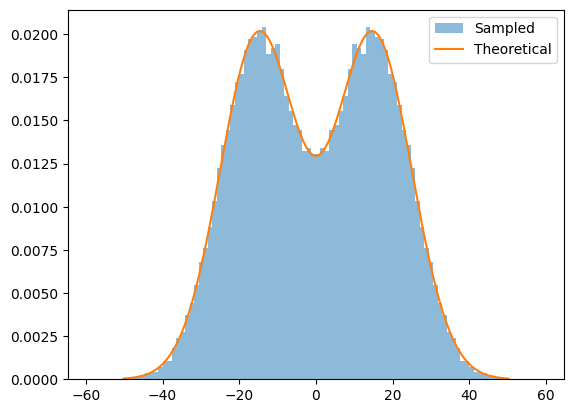

In [12]:
n_draws = 10
source_means = [mean_left, mean_right]
std = sigma_vals[0]
H = 0.1
Ntrials = 10000
X,Y = generate_trials(Ntrials,n_draws,source_means,std,H,mirror_trials=True,balanced_starts=True,seed=None)

x = np.arange(-50,50+0.1,0.1)
P_sample_g_left = norm.pdf(x, loc=mean_left, scale=std)
P_sample_g_right = norm.pdf(x, loc=mean_right, scale=std)
P_sample = (P_sample_g_left + P_sample_g_right) / 2

plt.hist(X.flatten(), bins=100, density=True, alpha=0.5, label='Sampled')
plt.plot(x,P_sample, label='Theoretical')
plt.legend()
plt.show()

In [13]:
P0 = np.array([[0.5], [0.5]])
p_YgX_sample = P_source_g_samples(X,mean_left,mean_right,std,H,P0,window_size=None)
N_threads = 14
IB_bound_0pt1 = get_mc_IB_bound(Y,p_YgX_sample,N_b=200,max_b=10,iterlimit=100000,beta_array=None,init='random', N_inits=3, betastar_array=None, N_threads=N_threads, seed=209, sort_by_beta=True)

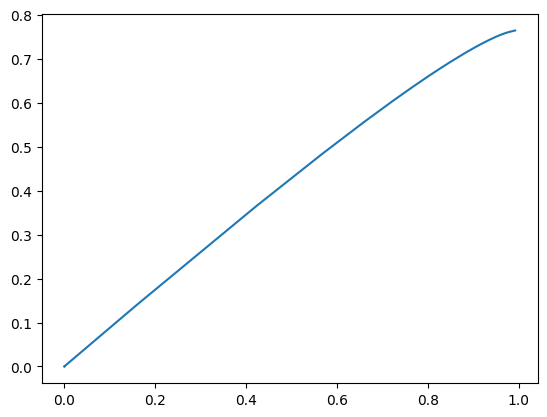

In [14]:
plt.plot(IB_bound_0pt1['I_XR'],IB_bound_0pt1['I_RY'])

In [16]:
P_source_g_samples(X[:5],mean_left,mean_right,std,H,P0,window_size=None)

array([[7.34764525e-05, 9.99926524e-01],
       [5.25815982e-06, 9.99994742e-01],
       [1.68588927e-04, 9.99831411e-01],
       [9.87780361e-01, 1.22196386e-02],
       [9.92820032e-01, 7.17996814e-03]])

In [17]:
X[:5]

array([[ 18.39844802,  18.80706505,   5.99991743,  34.96461453,
         16.19495119,  11.6181215 ,  25.41274543,  19.46328488,
          2.87136621,  25.56448595],
       [-13.7964805 , -24.97467852, -14.77110157, -15.22273688,
        -17.5456383 , -20.27377813,   7.83573547,   9.48324485,
         29.94060942,  33.19559984],
       [ -7.92466203,   4.55739101,  24.52863435,   8.77276522,
         19.81794619,   7.85251516,  13.87789242,  10.43368536,
          8.29892595,  21.90872255],
       [ -2.72654275, -12.62244028, -32.09720448, -26.96536807,
        -12.52146765, -22.44502694,  -5.30294767, -22.24189009,
        -10.2865879 ,  -7.46454941],
       [-41.78565638, -10.83987276,  29.74811822,  25.1036524 ,
         28.91793463,  27.37754041,   7.39831847, -29.7173136 ,
          1.6204012 , -12.27805016]])

In [18]:
Y[:5]

array([1, 1, 1, 0, 0])